# Exploratory Data Analysis — RAW_recipes.csv

Notebook ini melakukan:
- Load data dari `dataset/RAW_recipes.csv`
- Preprocessing (parse kolom list, bersihkan string, ekstrak fitur nutrisi, handle missing/duplikat)
- EDA (ringkasan data, missing values, distribusi, top tags/ingredients, korelasi, tren waktu)

In [16]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [ ]:
DATA_DIR = Path("dataset")
RAW_RECIPES_PATH = ".." / DATA_DIR / "RAW_recipes.csv"
assert RAW_RECIPES_PATH.exists(), f"File not found: {RAW_RECIPES_PATH.resolve()}"

df_raw = pd.read_csv(RAW_RECIPES_PATH)
print("Loaded:", RAW_RECIPES_PATH)
df_raw.shape

Loaded: dataset\RAW_recipes.csv


(231637, 12)

In [12]:
# Sample
print("Columns:", list(df_raw.columns))
display(df_raw.describe(include="all").T.head(30))

display(df_raw.head(5))

Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']


Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,231636,230185,cream cheese banana nut bread,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,231637.0,NaN,NaN,NaN,222014.708984,141206.635626,38.0,99944.0,207249.0,333816.0,537716.0
minutes,231637.0,NaN,NaN,NaN,9398.546009,4461963.03886,0.0,20.0,40.0,65.0,2147483647.0
contributor_id,231637.0,NaN,NaN,NaN,5534885.113838,99791408.213902,27.0,56905.0,173614.0,398275.0,2002289981.0
submitted,231637,5090,2000-03-06,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,231637,209115,"['15-minutes-or-less', 'time-to-make', 'course...",397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutrition,231637,229318,"[69.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_steps,231637.0,NaN,NaN,NaN,9.765499,5.995128,0.0,6.0,9.0,12.0,145.0
steps,231637,231074,['blend all ingredients until smooth'],20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,226658,222668,yum,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [13]:
# Missing values
missing = df_raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(30))

description    4979
name              1
dtype: int64

## Preprocessing

In [ ]:
# Preprocessing untuk parse list-like columns (misalnya 'tags', 'steps', 'ingredients', 'nutrition')
def _safe_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() in {"nan", "none", "null"}:
            return []
        try:
            v = ast.literal_eval(s)
            return v if isinstance(v, list) else []
        except Exception:
            return []
    return []

df = df_raw.copy()

# Normalize nama kolom (strip whitespace)
df.columns = [c.strip() for c in df.columns]

# Drop kolom duplikat
df = df.drop_duplicates().reset_index(drop=True)

# Membersihkan kolom string umum
for col in ["name", "description"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Parsing kolom yang berbentuk list (tags, steps, ingredients, nutrition)
list_cols = [c for c in ["tags", "steps", "ingredients", "nutrition"] if c in df.columns]
for col in list_cols:
    df[col] = df[col].map(_safe_list)

# Konversi ke tipe data yang sesuai
if "submitted" in df.columns:
    df["submitted"] = pd.to_datetime(df["submitted"], errors="coerce")

for col in ["minutes", "n_steps", "n_ingredients", "id", "contributor_id"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Handle negative value dalam kolom 'minutes'
if "minutes" in df.columns:
    df.loc[df["minutes"] < 0, "minutes"] = np.nan

# Tambahkan kolom baru untuk jumlah tags, steps, ingredients
for col in ["tags", "steps", "ingredients"]:
    if col in df.columns:
        df[f"n_{col}"] = df[col].map(len)

# Pisah nutrition list ke kolom terpisah
nutrition_cols = ["calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv", "protein_pdv", "sat_fat_pdv", "carbs_pdv"]
if "nutrition" in df.columns:
    nut = df["nutrition"].apply(lambda v: v if isinstance(v, list) else [])
    nut = nut.apply(lambda v: v + [np.nan] * (7 - len(v)) if len(v) < 7 else v[:7])
    nut_df = pd.DataFrame(nut.tolist(), columns=nutrition_cols)
    for c in nutrition_cols:
        nut_df[c] = pd.to_numeric(nut_df[c], errors="coerce")
    df = pd.concat([df.drop(columns=["nutrition"]), nut_df], axis=1)

After preprocessing shape: (231637, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   name            231636 non-null  string        
 1   id              231637 non-null  int64         
 2   minutes         231637 non-null  float64       
 3   contributor_id  231637 non-null  int64         
 4   submitted       231637 non-null  datetime64[ns]
 5   tags            231637 non-null  object        
 6   n_steps         231637 non-null  int64         
 7   steps           231637 non-null  object        
 8   description     226658 non-null  string        
 9   ingredients     231637 non-null  object        
 10  n_ingredients   231637 non-null  int64         
 11  n_tags          231637 non-null  int64         
 12  calories        231637 non-null  float64       
 13  total_fat_pdv   231637 non-null  float64       
 

,name,id,minutes,contributor_id,submitted,tags,n_steps,steps,description,ingredients,n_ingredients,n_tags,calories,total_fat_pdv,sugar_pdv,sodium_pdv,protein_pdv,sat_fat_pdv,carbs_pdv
0,arriba baked winter squash mexican style,137739,55.0,47892,2005-09-16,"[60-minutes-or-less, time-to-make, course, mai...",11,"[make a choice and proceed with recipe, depend...",autumn is my favorite time of year to cook! th...,"[winter squash, mexican seasoning, mixed spice...",7,20,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,31490,30.0,26278,2002-06-17,"[30-minutes-or-less, time-to-make, course, mai...",9,"[preheat oven to 425 degrees f, press dough in...",this recipe calls for the crust to be prebaked...,"[prepared pizza crust, sausage patty, eggs, mi...",6,20,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,112140,130.0,196586,2005-02-25,"[time-to-make, course, preparation, main-dish,...",6,"[brown ground beef in large pot, add chopped o...",this modified version of 'mom's' chili was a h...,"[ground beef, yellow onions, diced tomatoes, t...",13,9,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,alouette potatoes,59389,45.0,68585,2003-04-14,"[60-minutes-or-less, time-to-make, course, mai...",11,[place potatoes in a large pot of lightly salt...,"this is a super easy, great tasting, make ahea...","[spreadable cheese with garlic and herbs, new ...",11,30,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,amish tomato ketchup for canning,44061,190.0,41706,2002-10-25,"[weeknight, time-to-make, course, main-ingredi...",5,"[mix all ingredients& boil for 2 1 / 2 hours ,...",my dh's amish mother raised him on this recipe...,"[tomato juice, apple cider vinegar, sugar, sal...",8,21,352.9,1.0,337.0,23.0,3.0,0.0,28.0


,count,mean,std,min,25%,50%,75%,max
id,231637.0,2.220147e+05,1.412066e+05,38.0,99944.0,207249.0,333816.0,5.377160e+05
minutes,231637.0,9.398546e+03,4.461963e+06,0.0,20.0,40.0,65.0,2.147484e+09
contributor_id,231637.0,5.534885e+06,9.979141e+07,27.0,56905.0,173614.0,398275.0,2.002290e+09
n_steps,231637.0,9.765499e+00,5.995128e+00,0.0,6.0,9.0,12.0,1.450000e+02
n_ingredients,231637.0,9.051153e+00,3.734796e+00,1.0,6.0,9.0,11.0,4.300000e+01
n_tags,231637.0,1.788008e+01,7.244332e+00,1.0,13.0,17.0,22.0,7.300000e+01
calories,231637.0,4.739424e+02,1.189711e+03,0.0,174.4,313.4,519.7,4.343602e+05
total_fat_pdv,231637.0,3.608070e+01,7.779884e+01,0.0,8.0,20.0,41.0,1.718300e+04
sugar_pdv,231637.0,8.429687e+01,8.000809e+02,0.0,9.0,25.0,68.0,3.627290e+05
sodium_pdv,231637.0,3.014749e+01,1.319616e+02,0.0,5.0,14.0,33.0,2.933800e+04


In [ ]:
print("After preprocessing shape:", df.shape)
df.info()
display(df.head(5))

num_summary = df.select_dtypes(include=["number"]).describe().T
display(num_summary)

## EDA

### Missing Value

description    0.021495
name           0.000004
dtype: float64

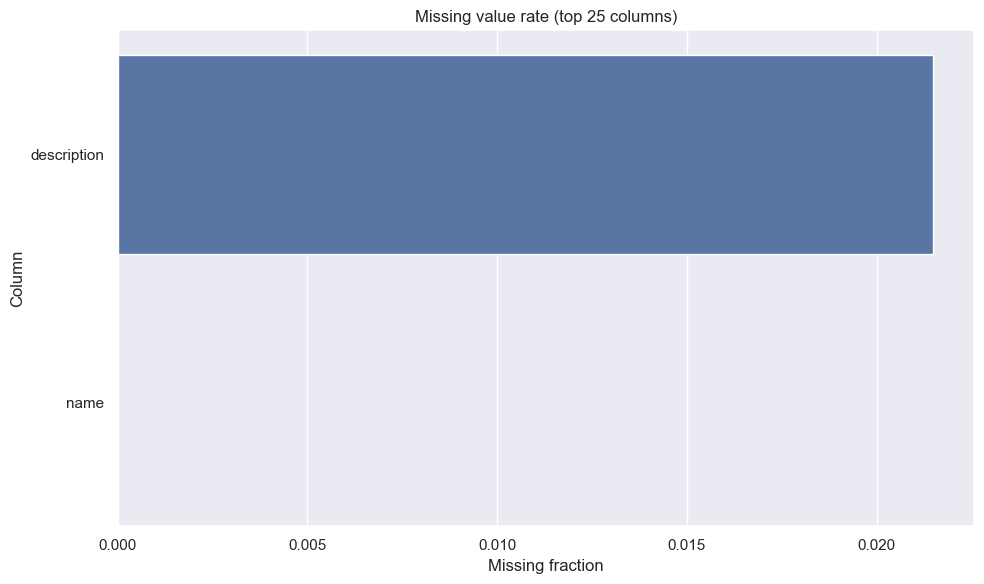

In [ ]:
na_rate = df.isna().mean().sort_values(ascending=False)
na_rate = na_rate[na_rate > 0]
display(na_rate.head(30))

plt.figure(figsize=(10, 6))
sns.barplot(x=na_rate.head(25).values, y=na_rate.head(25).index, orient="h")
plt.title("Missing value rate (top 25 columns)")
plt.xlabel("Missing fraction")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Distribusi Numerik

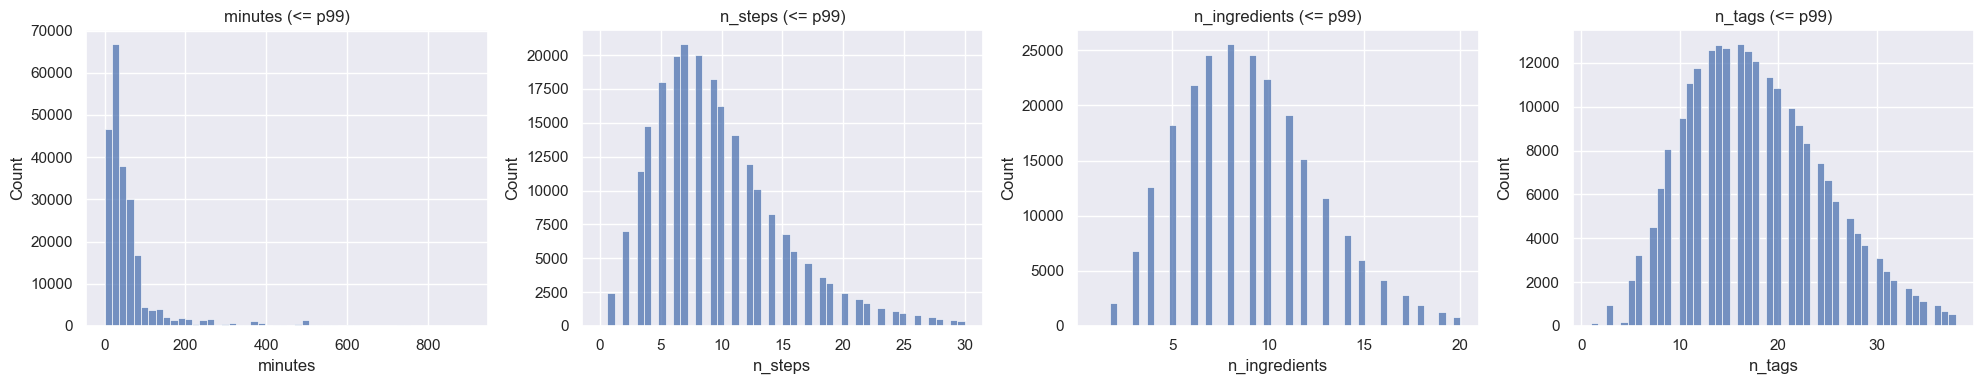

In [ ]:
num_candidates = [c for c in ["minutes", "n_steps", "n_ingredients", "n_tags", "n_steps", "n_ingredients", "n_ingredients"] if c in df.columns]
num_candidates = list(dict.fromkeys(num_candidates))

if num_candidates:
    fig, axes = plt.subplots(1, len(num_candidates), figsize=(5 * len(num_candidates), 4))
    if len(num_candidates) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_candidates):
        s = df[col].dropna()

        # Menghilangkan outlier ekstrem untuk readability
        upper = s.quantile(0.99)
        s_plot = s[s <= upper]
        sns.histplot(s_plot, bins=50, ax=ax)
        ax.set_title(f"{col} (<= p99)")

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom numerik yang ditemukan untuk analisis distribusi.")

### Distribusi Nutrisi

,count,mean,std,min,25%,50%,75%,max
calories,231637.0,473.942425,1189.711374,0.0,174.4,313.4,519.7,434360.2
total_fat_pdv,231637.0,36.080700,77.798840,0.0,8.0,20.0,41.0,17183.0
sugar_pdv,231637.0,84.296865,800.080897,0.0,9.0,25.0,68.0,362729.0
sodium_pdv,231637.0,30.147485,131.961589,0.0,5.0,14.0,33.0,29338.0
protein_pdv,231637.0,34.681860,58.472480,0.0,7.0,18.0,51.0,6552.0
sat_fat_pdv,231637.0,45.589150,98.235758,0.0,7.0,23.0,52.0,10395.0
carbs_pdv,231637.0,15.560403,81.824560,0.0,4.0,9.0,16.0,36098.0


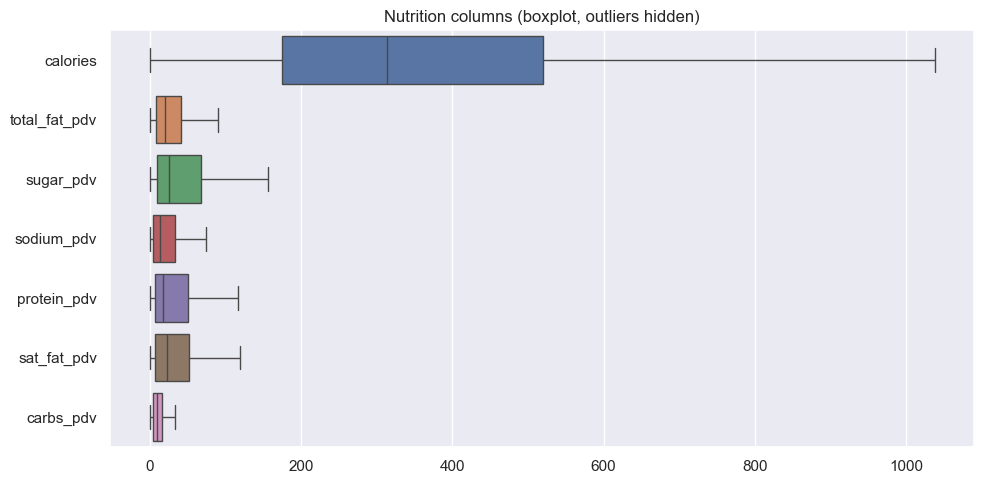

In [ ]:
nut_cols = [c for c in ["calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv", "protein_pdv", "sat_fat_pdv", "carbs_pdv"] if c in df.columns]
if nut_cols:
    display(df[nut_cols].describe().T)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df[nut_cols], orient="h", showfliers=False)
    plt.title("Nutrition columns (boxplot, outliers hidden)")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan kolom nutrisi yang diharapkan")

### Top tags & ingredient

tags
preparation           230546
time-to-make          225326
course                218148
main-ingredient       170446
dietary               165091
easy                  126062
occasion              114145
cuisine                91165
low-in-something       85776
main-dish              71786
equipment              70436
60-minutes-or-less     69990
number-of-servings     58949
meat                   56042
30-minutes-or-less     55077
vegetables             53814
taste-mood             52143
4-hours-or-less        49497
north-american         48479
3-steps-or-less        44933
Name: count, dtype: Int64

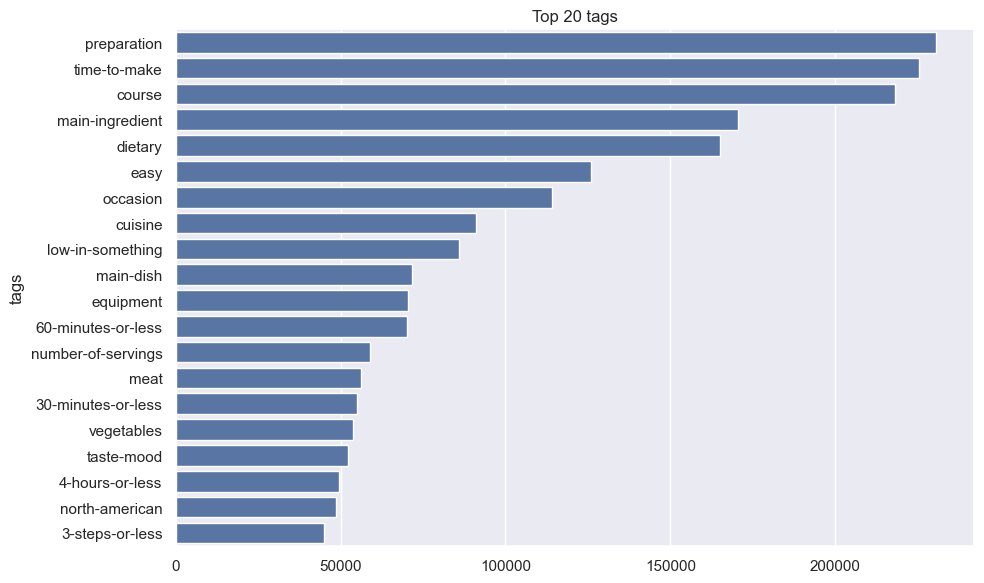

ingredients
salt                 85746
butter               54975
sugar                44535
onion                39065
water                34914
eggs                 33761
olive oil            32822
flour                26266
milk                 25786
garlic cloves        25748
pepper               22319
brown sugar          18655
garlic               18087
all-purpose flour    17659
baking powder        17504
egg                  17304
salt and pepper      15415
parmesan cheese      14807
lemon juice          14233
baking soda          14099
Name: count, dtype: Int64

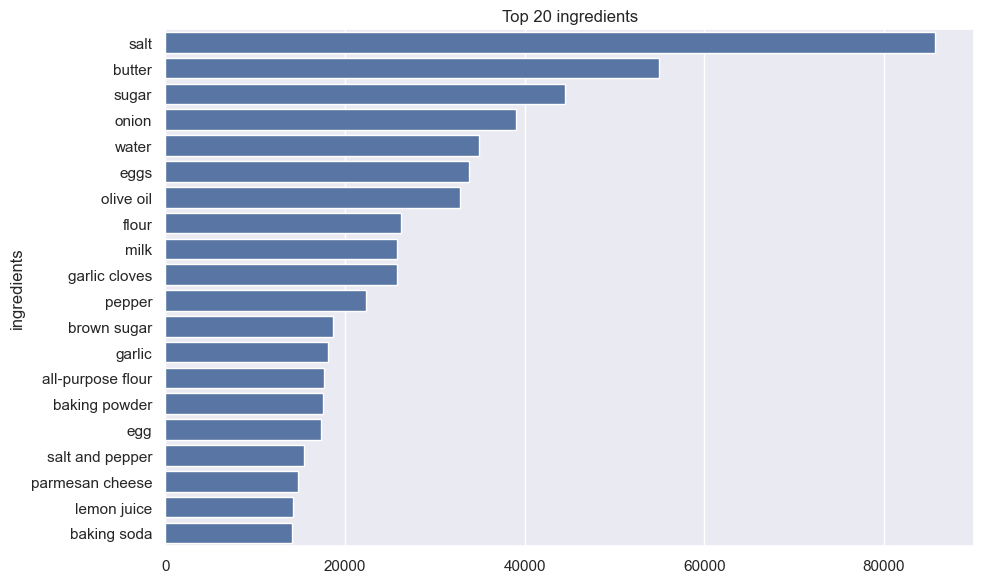

In [ ]:
def _top_tokens(series, top_n=20):
    if series is None:
        return pd.Series(dtype=int)
    exploded = series.explode()
    exploded = exploded.dropna()
    exploded = exploded.astype("string").str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

if "tags" in df.columns:
    top_tags = _top_tokens(df["tags"], top_n=20)
    display(top_tags)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_tags.values, y=top_tags.index, orient="h")
    plt.title("Top 20 tags")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan kolom 'tags'.")

if "ingredients" in df.columns:
    top_ing = _top_tokens(df["ingredients"], top_n=20)
    display(top_ing)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_ing.values, y=top_ing.index, orient="h")
    plt.title("Top 20 ingredients")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan kolom 'ingredients'.")

### Correlation

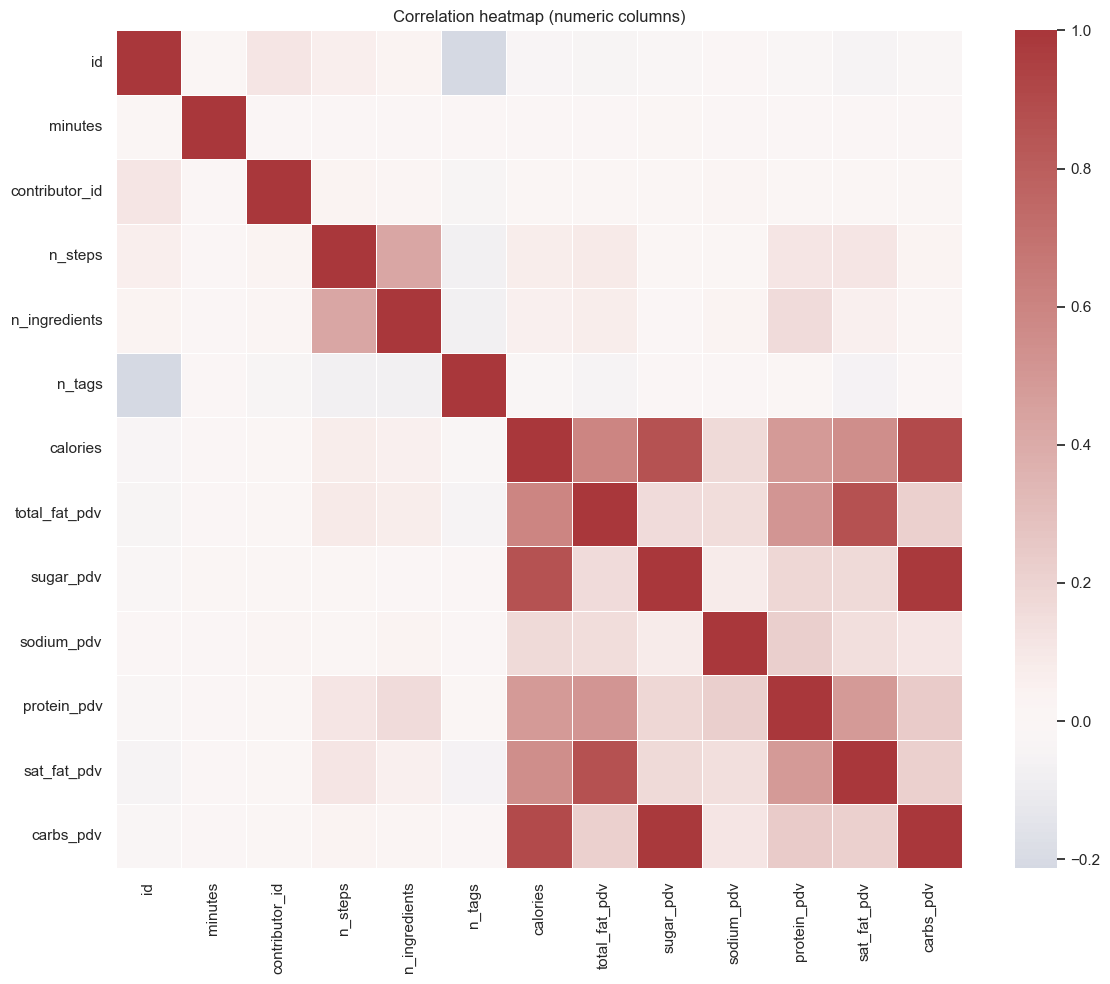

In [28]:
num_df = df.select_dtypes(include=["number"]).copy()
if not num_df.empty:
    corr = num_df.corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5)
    plt.title("Correlation heatmap (numeric columns)")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom numerik untuk correlation analysis.")

### Submission trend

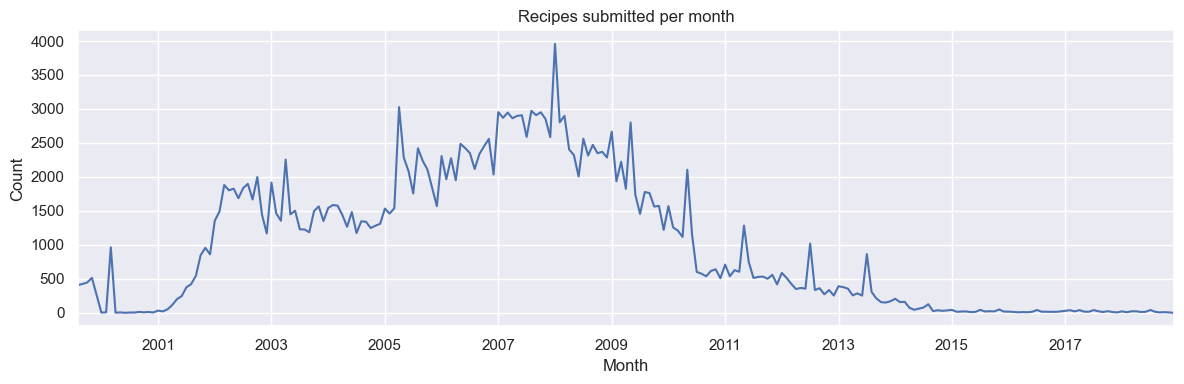

In [ ]:
if "submitted" in df.columns and pd.api.types.is_datetime64_any_dtype(df["submitted"]):
    ts = df.dropna(subset=["submitted"]).copy()
    if not ts.empty:
        ts["submitted_month"] = ts["submitted"].dt.to_period("M").dt.to_timestamp()
        monthly = ts.groupby("submitted_month").size()
        plt.figure(figsize=(12, 4))
        monthly.plot()
        plt.title("Recipes submitted per month")
        plt.xlabel("Month")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada tanggal pengiriman yang valid.")
else:
    print("Kolom 'submitted' tidak tersedia sebagai datetime.")